In [1]:
# =========================================================
# MÉTODO PANEL CON EFECTOS FIJOS
# ¿El efecto de la democracia sobre la exclusión es real dentro
# de cada país, o solo refleja que países distintos son distintos?
# (2000-2023)
# =========================================================

# =========================================================
# CELDA 1: Instalar dependencias
# ---------------------------------------------------------
# Objetivo:
#   Instalar la librería `linearmodels`, necesaria para
#   estimar modelos de datos panel (Pooled OLS y efectos
#   fijos), ya que no viene instalada por defecto en
#   Google Colab.
#
# Resultado:
#   El entorno queda listo para ejecutar modelos panel.
# =========================================================

!pip install -q linearmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS, PooledOLS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.2 MB/s eta 0:00:00


In [2]:
# =========================================================
# CELDA 2: Cargar y preparar los datos
# ---------------------------------------------------------
# Objetivo:
#   - Leer la base de datos de V-Dem.
#   - Filtrar únicamente el período 2000–2023 para trabajar
#     con una ventana temporal consistente.
#
# Resultado:
#   df21 contiene la base que será utilizada en todos los
#   modelos de panel.
# =========================================================

df = pd.read_csv('/content/vdem_exclusion_subset.csv')
df21 = df[(df['year'] >= 2000) & (df['year'] <= 2023)].copy()

In [4]:
# =========================================================
# CELDA 3: Comparar modelos Pooled OLS y Efectos Fijos
# ---------------------------------------------------------
# Objetivo:
#   Estimar dos modelos para evaluar si la relación entre
#   democracia y exclusión permanece cuando se controlan
#   las características propias de cada país.
#
# Modelos estimados:
#   • Pooled OLS:
#       Trata cada observación país-año como independiente.
#
#   • Efectos Fijos (FE):
#       Controla las características invariables de cada
#       país y los cambios comunes de cada año.
#
# Además:
#   - Calcula errores estándar clusterizados por país.
#   - Muestra coeficientes y medidas de ajuste.
#
# Devuelve:
#   1. Modelo Pooled.
#   2. Modelo de Efectos Fijos.
#   3. Base preparada para análisis posteriores.
# =========================================================

def comparar_pooled_vs_fe(data, target, predictores=['v2x_polyarchy', 'log_gdppc']):
    sub = data.dropna(subset=[target, 'v2x_polyarchy', 'e_gdppc']).copy()
    sub['log_gdppc'] = np.log(sub['e_gdppc'])
    sub = sub.set_index(['country_name', 'year'])

    y = sub[target]
    X = sub[predictores]

    # Pooled: ignora la estructura de panel, trata cada país-año como
    # independiente (esto es, en el fondo, lo mismo que la regresión
    # de residuales de la vuelta anterior, sin dummies de región)
    pooled = PooledOLS(y, X).fit(cov_type='clustered', cluster_entity=True)

    # Efectos fijos de país + año, errores clusterizados por país
    fe = PanelOLS(y, X, entity_effects=True, time_effects=True).fit(
        cov_type='clustered', cluster_entity=True
    )

    print(f"=== {target} | N={len(sub)} | Países={sub.index.get_level_values(0).nunique()} ===\n")
    print("--- POOLED (sin efectos fijos) ---")
    print(pooled.summary.tables[1])
    print(f"R² (overall): {pooled.rsquared:.3f}\n")

    print("--- EFECTOS FIJOS (país + año, SE clusterizados) ---")
    print(fe.summary.tables[1])
    print(f"R² (within): {fe.rsquared_within:.3f}\n")

    return pooled, fe, sub

In [5]:
# =========================================================
# CELDA 4: Modelo para exclusión por grupo social
# ---------------------------------------------------------
# Objetivo:
#   Comparar el modelo Pooled y el modelo con efectos
#   fijos utilizando como variable dependiente la
#   exclusión de grupos sociales.
#
# Esto permite evaluar si el efecto de la democracia se
# mantiene cuando la comparación se hace dentro de cada
# país a lo largo del tiempo.
# =========================================================

pooled_socgr, fe_socgr, datos_socgr = comparar_pooled_vs_fe(df21, 'v2xpe_exlsocgr')

=== v2xpe_exlsocgr | N=3469 | Países=174 ===

--- POOLED (sin efectos fijos) ---
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
v2x_polyarchy    -0.1735     0.0832    -2.0848     0.0372     -0.3366     -0.0103
log_gdppc         0.1232     0.0151     8.1871     0.0000      0.0937      0.1527
R² (overall): 0.415

--- EFECTOS FIJOS (país + año, SE clusterizados) ---
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
v2x_polyarchy    -0.1946     0.0356    -5.4628     0.0000     -0.2644     -0.1247
log_gdppc        -0.0277     0.0163    -1.7009     0.0891     -0.0596      0.0042
R² (within): 0.165



In [6]:
# =========================================================
# CELDA 5: Modelo para exclusión de género
# ---------------------------------------------------------
# Objetivo:
#   Repetir el análisis anterior utilizando como variable
#   dependiente la exclusión por género.
#
# Los resultados pueden compararse posteriormente con los
# obtenidos para la exclusión de grupos sociales.
# =========================================================

pooled_gen, fe_gen, datos_gen = comparar_pooled_vs_fe(df21, 'v2xpe_exlgender')

=== v2xpe_exlgender | N=3469 | Países=174 ===

--- POOLED (sin efectos fijos) ---
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
v2x_polyarchy    -0.1236     0.0816    -1.5138     0.1302     -0.2836      0.0365
log_gdppc         0.1092     0.0147     7.4036     0.0000      0.0803      0.1381
R² (overall): 0.426

--- EFECTOS FIJOS (país + año, SE clusterizados) ---
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
v2x_polyarchy    -0.1405     0.0304    -4.6202     0.0000     -0.2002     -0.0809
log_gdppc        -0.0224     0.0171    -1.3123     0.1895     -0.0558      0.0111
R² (within): 0.214



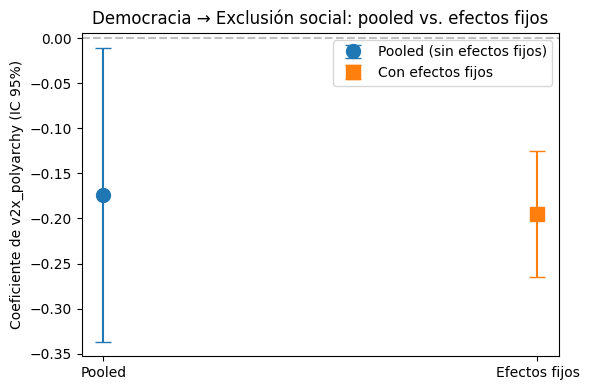

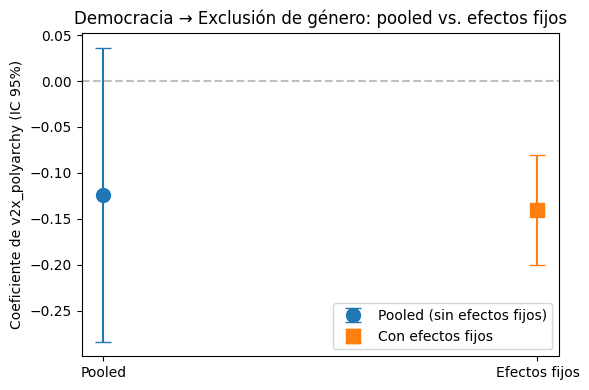

In [7]:
# =========================================================
# CELDA 6: Comparación visual entre modelos
# ---------------------------------------------------------
# Objetivo:
#   Comparar gráficamente el coeficiente asociado a la
#   democracia en los modelos Pooled y de Efectos Fijos.
#
# El gráfico muestra:
#   - El coeficiente estimado.
#   - Su intervalo de confianza al 95%.
#
# Interpretación:
#   Si ambos coeficientes son similares, el efecto de la
#   democracia no depende únicamente de diferencias entre
#   países, sino que también aparece dentro de cada país
#   a lo largo del tiempo.
# =========================================================

def graficar_comparacion(pooled, fe, titulo):
    coef_pooled = pooled.params['v2x_polyarchy']
    ci_pooled = pooled.conf_int().loc['v2x_polyarchy']  # índice: 'lower', 'upper'
    coef_fe = fe.params['v2x_polyarchy']
    ci_fe = fe.conf_int().loc['v2x_polyarchy']

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar([0], [coef_pooled],
                yerr=[[coef_pooled - ci_pooled['lower']], [ci_pooled['upper'] - coef_pooled]],
                fmt='o', capsize=6, label='Pooled (sin efectos fijos)', markersize=10)
    ax.errorbar([1], [coef_fe],
                yerr=[[coef_fe - ci_fe['lower']], [ci_fe['upper'] - coef_fe]],
                fmt='s', capsize=6, label='Con efectos fijos', markersize=10)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pooled', 'Efectos fijos'])
    ax.set_ylabel('Coeficiente de v2x_polyarchy (IC 95%)')
    ax.set_title(titulo)
    ax.legend()
    plt.tight_layout()
    plt.show()

graficar_comparacion(pooled_socgr, fe_socgr,
                      'Democracia → Exclusión social: pooled vs. efectos fijos')
graficar_comparacion(pooled_gen, fe_gen,
                      'Democracia → Exclusión de género: pooled vs. efectos fijos')

In [8]:
# =========================================================
# CELDA 7: Analizar efectos fijos por país
# ---------------------------------------------------------
# Objetivo:
#   Extraer el efecto fijo promedio de cada país,
#   interpretado como su nivel base de exclusión una vez
#   controlados democracia, riqueza y efectos temporales.
#
# Este efecto representa diferencias estructurales entre
# países y no debe confundirse con los residuales del
# modelo de regresión.
#
# Se muestran los países con los valores más altos y más
# bajos del efecto fijo estimado.
# =========================================================

fe_effects_socgr = fe_socgr.estimated_effects.groupby('country_name').mean()
fe_effects_socgr.columns = ['efecto_fijo']
print("Países con el efecto fijo (línea base) más alto de exclusión social:")
print(fe_effects_socgr.sort_values('efecto_fijo', ascending=False).head(10).round(3))
print("\nPaíses con el efecto fijo más bajo:")
print(fe_effects_socgr.sort_values('efecto_fijo').head(10).round(3))

Países con el efecto fijo (línea base) más alto de exclusión social:
                          efecto_fijo
country_name                         
Mauritania                      1.037
Sudan                           1.017
Yemen                           1.009
Bahrain                         1.006
Guatemala                       0.995
Equatorial Guinea               0.988
South Sudan                     0.983
Republic of the Congo           0.970
Iraq                            0.966
Central African Republic        0.963

Países con el efecto fijo más bajo:
              efecto_fijo
country_name             
Belarus             0.211
Armenia             0.235
Niger               0.285
Lithuania           0.291
Vanuatu             0.300
Singapore           0.302
Cuba                0.303
Burkina Faso        0.312
Latvia              0.313
South Korea         0.313


In [9]:
# =========================================================
# CELDA 8: Exportar resultados
# ---------------------------------------------------------
# Objetivo:
#   Construir un resumen con los principales coeficientes
#   obtenidos en ambos modelos y exportarlo como archivo
#   CSV para facilitar su uso en tablas, gráficos o en la
#   redacción del artículo.
#
# Archivo generado:
#   - resumen_efectos_fijos.csv
# =========================================================

resumen = pd.DataFrame({
    'variable': ['v2xpe_exlsocgr', 'v2xpe_exlgender'],
    'coef_pooled_polyarchy': [pooled_socgr.params['v2x_polyarchy'], pooled_gen.params['v2x_polyarchy']],
    'coef_fe_polyarchy': [fe_socgr.params['v2x_polyarchy'], fe_gen.params['v2x_polyarchy']],
    'r2_within_fe': [fe_socgr.rsquared_within, fe_gen.rsquared_within],
})
resumen.to_csv('/content/resumen_efectos_fijos.csv', index=False)
print(resumen)


# --- NOTA METODOLÓGICA PARA EL ARTÍCULO ---
# Un coeficiente FE similar o mayor que el pooled es evidencia de que el
# efecto NO es solo un artefacto de comparar países distintos entre sí.
# PERO esto sigue siendo asociación, no causalidad: la causalidad inversa
# (menos exclusión de grupos sociales facilita procesos de democratización,
# en vez de ser consecuencia de ellos) no queda descartada por un panel de
# efectos fijos. Para acercarse más a causalidad haría falta una estrategia
# de identificación (variables instrumentales, diseño de discontinuidad,
# o al menos rezagar el predictor un período) - decisión para la siguiente
# vuelta si quieres profundizar en esa dirección.

          variable  coef_pooled_polyarchy  coef_fe_polyarchy  r2_within_fe
0   v2xpe_exlsocgr              -0.173465          -0.194586      0.164606
1  v2xpe_exlgender              -0.123559          -0.140526      0.213999
